## Part A: Functions
If `numba` is missing, use:

```python
%pip install numba
```

## A.1 Imports

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pickle
import os

from dataclasses import dataclass, replace, asdict
from time import perf_counter
from pathlib import Path

from matplotlib.animation import FuncAnimation
from IPython.display import HTML
from matplotlib.patches import Circle
from matplotlib.colors import Normalize

from matplotlib.animation import PillowWriter

try:
    from numba import njit
    NUMBA_AVAILABLE = True
except ImportError:
    NUMBA_AVAILABLE = False
    raise ImportError(
        "This fast notebook needs numba. Install it with: %pip install numba, "
        "then restart the kernel."
    )

plt.rcParams["figure.figsize"] = (7, 4)
plt.rcParams["axes.grid"] = False

## A.2 Parameter class

In [3]:
@dataclass
class ModelParameters:
    N: int = 400
    dt: float = 0.1
    steps: int = 1_000_000
    save_every: int = 128
    snapshot_every: int = 0
    snapshot_after: int = 0
    progress_every: int = 0

    # Paper-style dimensionless parameters
    lambda_s: float = 0.07
    lambda_a: float = 0.30
    lambda_n: float = 0.03
    lambda_Fin: float = 0.3
    lambda_Tin: float = 3.0

    # Fixed dimensionless constants
    a_bar: float = 1.0
    radius_std: float = 0.1
    k_rep: float = 1.0
    zeta: float = 1.0
    chi: float = 1.0

    # Neighbor cutoff from the paper
    neighbor_cutoff: float = 2.7

    # Initial condition
    initial_width_particles: int = 20
    initial_spacing: float = 2.0
    position_jitter: float = 0.05
    initial_angle_noise: float = np.pi / 4

    seed: int = 1

    @property
    def total_time(self):
        return self.steps * self.dt

## A.3 Initialization and misc. functions

In [5]:
def initialize_particles(params: ModelParameters):
    """Create the initial particle positions, angles and radii."""
    rng = np.random.default_rng(params.seed)
    N = params.N

    radii = rng.normal(loc=params.a_bar, scale=params.radius_std, size=N)
    radii = np.clip(radii, 0.7 * params.a_bar, 1.3 * params.a_bar)

    width = params.initial_width_particles
    height = int(np.ceil(N / width))

    positions = []
    for row in range(height):
        for col in range(width):
            if len(positions) >= N:
                break
            positions.append([col * params.initial_spacing, row * params.initial_spacing])

    positions = np.asarray(positions, dtype=np.float64)
    positions -= positions.mean(axis=0)
    positions += params.position_jitter * rng.normal(size=positions.shape)

    angles = rng.uniform(
        low=-params.initial_angle_noise,
        high=params.initial_angle_noise,
        size=N,
    ).astype(np.float64)

    return positions, angles, radii.astype(np.float64)


def unit_vectors(angles):
    return np.column_stack((np.cos(angles), np.sin(angles)))


def final_boundary_information_python(positions, cutoff):
    """Simple Python version used only for plotting the final snapshot."""
    N = len(positions)
    is_boundary = np.zeros(N, dtype=bool)

    for i in range(N):
        rel = positions - positions[i]
        dist = np.linalg.norm(rel, axis=1)
        mask = (dist < cutoff) & (dist > 1e-12)

        if not np.any(mask):
            is_boundary[i] = True
            continue

        angles = np.sort(np.mod(np.arctan2(rel[mask, 1], rel[mask, 0]), 2 * np.pi))
        gaps = np.diff(np.concatenate([angles, [angles[0] + 2 * np.pi]]))
        is_boundary[i] = gaps.max() >= np.pi

    return is_boundary

## A.4 Simulation code

In [7]:
@njit
def _signed_angle_difference(target, current):
    return np.arctan2(np.sin(target - current), np.cos(target - current))


@njit
def _run_simulation_core(
    positions,
    angles,
    radii,
    steps,
    dt,
    save_every,
    snapshot_every,
    snapshot_after,
    progress_every,
    lambda_s,
    lambda_a,
    lambda_n,
    lambda_Fin,
    lambda_Tin,
    k_rep,
    zeta,
    chi,
    a_bar,
    neighbor_cutoff,
    seed
):

    np.random.seed(seed)

    N = positions.shape[0]
    n_saves = steps // save_every + 1

    time = np.empty(n_saves)
    phi = np.empty(n_saves)
    angular_order = np.empty(n_saves)
    com = np.empty((n_saves, 2))
    rms_radius = np.empty(n_saves)

    forces = np.empty((N, 2))
    torques = np.empty(N)

    # Dense temporary storage for neighbor angles used for the boundary test.
    # N=400 -> this is small. It avoids Python lists inside the loop.
    neighbor_angles = np.empty((N, N))
    neighbor_counts = np.empty(N, dtype=np.int64)

    align_sum = np.empty(N)
    align_count = np.empty(N, dtype=np.int64)

    final_boundary = np.zeros(N, dtype=np.bool_)
    cutoff2 = neighbor_cutoff * neighbor_cutoff
    noise_amp = np.sqrt(2.0 * lambda_n / dt)

    save_index = 0

    n_snapshots = ((steps - snapshot_after) // snapshot_every) + 1 if snapshot_every != 0 and snapshot_after <= steps else 0
    saved_snapshots = np.empty((n_snapshots, N, 3))
    snapshot_index = 0
    
    for step in range(steps + 1):
        # Save current summary before doing the next update.
        if step % save_every == 0:
            sx = 0.0
            sy = 0.0
            cx = 0.0
            cy = 0.0

            for i in range(N):
                sx += np.cos(angles[i])
                sy += np.sin(angles[i])
                cx += positions[i, 0]
                cy += positions[i, 1]

            sx /= N
            sy /= N
            cx /= N
            cy /= N

            tangential_sum = 0.0
            rr_sum = 0.0
            for i in range(N):
                rx = positions[i, 0] - cx
                ry = positions[i, 1] - cy
                r = np.sqrt(rx * rx + ry * ry)
                rr_sum += r * r

                if r > 1e-12:
                    ux = np.cos(angles[i])
                    uy = np.sin(angles[i])
                    # Tangential unit vector around the center of mass.
                    tx = -ry / r
                    ty = rx / r
                    tangential_sum += ux * tx + uy * ty

            time[save_index] = step * dt
            phi[save_index] = np.sqrt(sx * sx + sy * sy)
            angular_order[save_index] = abs(tangential_sum / N)
            com[save_index, 0] = cx
            com[save_index, 1] = cy
            rms_radius[save_index] = np.sqrt(rr_sum / N)
            save_index += 1

        
        if snapshot_every != 0 and step >= snapshot_after and step % snapshot_every == 0:
            for i in range(N):
                saved_snapshots[snapshot_index, i, 0] = positions[i, 0]
                saved_snapshots[snapshot_index, i, 1] = positions[i, 1]
                saved_snapshots[snapshot_index, i, 2] = angles[i]
            snapshot_index += 1
            
        
        if step == steps:
            break

        if progress_every > 0 and step > 0 and step % progress_every == 0:
            print("step", step, "of", steps)

        # Reset arrays and add self propulsion.
        for i in range(N):
            forces[i, 0] = lambda_s * np.cos(angles[i])
            forces[i, 1] = lambda_s * np.sin(angles[i])
            torques[i] = 0.0
            neighbor_counts[i] = 0
            align_sum[i] = 0.0
            align_count[i] = 0
            final_boundary[i] = False

        # Pair loop: neighbors, repulsion, and alignment mismatch sums.
        for i in range(N - 1):
            xi = positions[i, 0]
            yi = positions[i, 1]

            for j in range(i + 1, N):
                dx = xi - positions[j, 0]
                dy = yi - positions[j, 1]
                d2 = dx * dx + dy * dy

                if d2 < cutoff2:
                    d = np.sqrt(d2)
                    if d > 1e-12:
                        ci = neighbor_counts[i]
                        neighbor_angles[i, ci] = np.arctan2(-dy, -dx)
                        neighbor_counts[i] = ci + 1

                        cj = neighbor_counts[j]
                        neighbor_angles[j, cj] = np.arctan2(dy, dx)
                        neighbor_counts[j] = cj + 1

                        align_sum[i] += _signed_angle_difference(angles[j], angles[i])
                        align_sum[j] += _signed_angle_difference(angles[i], angles[j])
                        align_count[i] += 1
                        align_count[j] += 1

                        preferred_distance = radii[i] + radii[j]
                        if d < preferred_distance:
                            overlap = preferred_distance - d
                            fx = k_rep * overlap * dx / d
                            fy = k_rep * overlap * dy / d
                            forces[i, 0] += fx
                            forces[i, 1] += fy
                            forces[j, 0] -= fx
                            forces[j, 1] -= fy

        # Boundary criterion, inward torque, alignment torque, and noise.
        for i in range(N):
            if align_count[i] > 0:
                torques[i] += lambda_a * align_sum[i] / align_count[i]

            count = neighbor_counts[i]
            theta_out = 2.0 * np.pi
            inward_angle = 0.0

            if count > 0:
                # Convert to [0, 2pi).
                for k in range(count):
                    a = neighbor_angles[i, k]
                    a = a % (2.0 * np.pi)
                    neighbor_angles[i, k] = a

                # Insertion sort. Neighbor counts are small, so this is cheap.
                for k in range(1, count):
                    key = neighbor_angles[i, k]
                    m = k - 1
                    while m >= 0 and neighbor_angles[i, m] > key:
                        neighbor_angles[i, m + 1] = neighbor_angles[i, m]
                        m -= 1
                    neighbor_angles[i, m + 1] = key

                max_gap = -1.0
                max_index = 0
                for k in range(count - 1):
                    gap = neighbor_angles[i, k + 1] - neighbor_angles[i, k]
                    if gap > max_gap:
                        max_gap = gap
                        max_index = k

                wrap_gap = neighbor_angles[i, 0] + 2.0 * np.pi - neighbor_angles[i, count - 1]
                if wrap_gap > max_gap:
                    max_gap = wrap_gap
                    max_index = count - 1

                theta_out = max_gap
                outward_angle = neighbor_angles[i, max_index] + theta_out / 2.0
                inward_angle = (outward_angle + np.pi) % (2.0 * np.pi)

            if theta_out >= np.pi:
                final_boundary[i] = True
                boundary_strength = theta_out - np.pi

                # Same convention as the original notebook: boundary force along the particle orientation,
                # while the torque turns the particle inward.
                forces[i, 0] += boundary_strength * lambda_Fin * np.cos(angles[i])
                forces[i, 1] += boundary_strength * lambda_Fin * np.sin(angles[i])
                torques[i] += lambda_Tin * _signed_angle_difference(inward_angle, angles[i])

            # Binary orientational noise, matching the earlier notebook convention.
            xi = 1.0
            if np.random.random() < 0.5:
                xi = -1.0
            torques[i] += noise_amp * xi

        # Overdamped update.
        for i in range(N):
            alpha = radii[i] / a_bar
            positions[i, 0] += dt * forces[i, 0] / (alpha * zeta)
            positions[i, 1] += dt * forces[i, 1] / (alpha * zeta)
            angles[i] += dt * torques[i] / (alpha * alpha * chi)
            angles[i] = (angles[i] + np.pi) % (2.0 * np.pi) - np.pi

    
    
    return time, phi, angular_order, com, rms_radius, positions, angles, final_boundary, saved_snapshots
    
def _run_simulation(
    positions,
    angles,
    radii,
    params
):
    start = perf_counter()

    (
        time,
        phi,
        angular_order,
        com,
        rms_radius,
        final_positions,
        final_angles,
        final_boundary,
        saved_snapshots,
    ) = _run_simulation_core(
        positions,
        angles,
        radii,
        params.steps,
        params.dt,
        params.save_every,
        params.snapshot_every,
        params.snapshot_after,
        params.progress_every,
        params.lambda_s,
        params.lambda_a,
        params.lambda_n,
        params.lambda_Fin,
        params.lambda_Tin,
        params.k_rep,
        params.zeta,
        params.chi,
        params.a_bar,
        params.neighbor_cutoff,
        params.seed,
        )
    
    runtime = perf_counter() - start

    return {
        "time": time,
        "phi": phi,
        "angular_order": angular_order,
        "center_of_mass": com,
        "rms_radius": rms_radius,
        "final_positions": positions.copy(),
        "final_angles": angles.copy(),
        "radii": radii.copy(),
        "final_boundary": final_boundary.copy(),
        "params": asdict(params),
        "saved_snapshots": saved_snapshots,
        "runtime_seconds": runtime
    }
    
    

## A.5 Time Estimation function

In [9]:
def estimate_runtime_from_benchmark(params: ModelParameters, benchmark_steps=20_000):
    """Run a short benchmark and estimate the runtime for params.steps."""
    bench_params = replace(params, steps=benchmark_steps)
    
    positions, angles, radii = initialize_particles(bench_params)
    result = _run_simulation(positions, angles, radii, bench_params)
    
    seconds_per_step = result["runtime_seconds"] / benchmark_steps
    estimated_seconds = seconds_per_step * params.steps

    print(f"Benchmark: {benchmark_steps:,} steps in {result['runtime_seconds']:.2f} s")
    print(f"Speed: {1 / seconds_per_step:,.0f} steps/s")
    print(f"Estimated runtime for {params.steps:,} steps: {estimated_seconds / 60:.1f} min")

    return result, estimated_seconds 

## A.6 Analysis functions

In [11]:
def plot_summary(summary, title=""):
    time = summary["time"]

    fig, ax = plt.subplots(figsize=(8, 4))
    ax.plot(time, summary["phi"], label=r"$\phi$")
    ax.plot(time, summary["angular_order"], label="angular order")
    ax.set_xlabel(r"time / $\tau$")
    ax.set_ylabel("order parameter")
    ax.set_ylim(0, 1.05)
    ax.legend()
    ax.set_title(title)
    plt.tight_layout()
    plt.show()

    fig, ax = plt.subplots(figsize=(5, 4))
    late = slice(len(time) // 2, None)
    ax.hist(summary["phi"][late], bins=40, density=True)
    ax.set_xlabel(r"late-time $\phi$")
    ax.set_ylabel("probability density")
    ax.set_title("Late-time order-parameter histogram")
    plt.tight_layout()
    plt.show()

    com = summary["center_of_mass"]
    fig, ax = plt.subplots(figsize=(5, 5))
    ax.plot(com[:, 0], com[:, 1])
    ax.set_aspect("equal")
    ax.set_xlabel(r"$x_{CM}$")
    ax.set_ylabel(r"$y_{CM}$")
    ax.set_title("Center-of-mass trajectory")
    plt.tight_layout()
    plt.show()


def summarize_late_time(summary, transient_fraction=0.5): # misschien dit analysis noemen?
    start = int(transient_fraction * len(summary["time"]))
    dt_saved = np.diff(summary["time"]).mean() if len(summary["time"]) > 1 else np.nan
    com = summary["center_of_mass"]

    if len(com[start:]) > 2:
        displacement = np.linalg.norm(com[-1] - com[start])
        duration = summary["time"][-1] - summary["time"][start]
        mean_com_speed = displacement / duration if duration > 0 else np.nan
    else:
        mean_com_speed = np.nan

    return {
        "mean_phi": float(np.mean(summary["phi"][start:])),
        "std_phi": float(np.std(summary["phi"][start:])),
        "mean_angular": float(np.mean(summary["angular_order"][start:])),
        "std_angular": float(np.std(summary["angular_order"][start:])),
        "mean_rms_radius": float(np.mean(summary["rms_radius"][start:])),
        "mean_com_speed": float(mean_com_speed),
        "runtime_seconds": float(summary["runtime_seconds"]),
        "n_saved": int(len(summary["time"])),
        "dt_saved": float(dt_saved),
    }

# This is deliberately simple. Use it for screening sweeps, then inspect the interesting cases manually.

# Typical interpretation:

# - high `mean_phi` → migrating
# - low `mean_phi` and high `mean_angular` → rotating
# - high fluctuations in `phi` → switching / mixed
# - low everything → jammed or unclear

def classify_state(summary, transient_fraction=0.5):
    stats = summarize_late_time(summary, transient_fraction=transient_fraction)

    mean_phi = stats["mean_phi"]
    std_phi = stats["std_phi"]
    mean_angular = stats["mean_angular"]
    mean_com_speed = stats["mean_com_speed"]

    if mean_phi > 0.35 and mean_com_speed > 1e-3:
        state = "migrating"
    elif mean_phi < 0.25 and mean_angular > 0.35:
        state = "rotating"
    elif std_phi > 0.12 and mean_phi > 0.15:
        state = "mixed/switching"
    elif mean_phi < 0.15 and mean_angular < 0.20:
        state = "jammed/unclear"
    else:
        state = "unclear/mixed"

    return {"state": state, **stats}

## A.7 Benchmark

In [195]:
benchmark_params = ModelParameters(
    N=400,
    steps=1_000_000,
    save_every=128,
    dt=0.1,
    lambda_s=0.07,
    lambda_a=0.30,
    seed=3,
)

# First call compiles the numba function; it may be slower.
positions, angles, radii = initialize_particles(benchmark_params)
_ = _run_simulation(positions, angles, radii, replace(benchmark_params, steps=1000))

print('Called NUMBA once.')
# Clean benchmark after compilation.
benchmark_summary, estimated_seconds = estimate_runtime_from_benchmark(benchmark_params, benchmark_steps=20_000)

Called NUMBA once.
Benchmark: 20,000 steps in 11.68 s
Speed: 1,713 steps/s
Estimated runtime for 1,000,000 steps: 9.7 min


## Part B: Run and save simulations

## B.1 Saving functions

In [13]:
def make_filename(params):
    return (
        f"N{params.N}"
        f"_ls{params.lambda_s:.4f}"
        f"_la{params.lambda_a:.4f}"
        f"_ln{params.lambda_n:.4f}"
        f"_seed{params.seed}"
        f"_steps{params.steps}"
        f"_dt{params.dt:.4f}"
        ".pkl"
    )

def run_and_save(
    params,
    output_dir="saved_sims"
):
    os.makedirs(output_dir, exist_ok=True)
    positions, angles, radii = initialize_particles(params)
    summary = _run_simulation(positions, angles, radii, params)

    data = {
        "params": params,
        "summary": summary,
    }

    filename = make_filename(params)
    path = os.path.join(output_dir, filename)

    with open(path, "wb") as f:
        pickle.dump(data, f)

    print(f"Saved: {path}")

    return

## B.2 Running and saving a single

In [193]:
params = ModelParameters(
    N=400,
    steps=100_000,
    save_every=128,
    snapshot_every=0,
    snapshot_after=0,
    progress_every=10_000,
    dt=0.1,

    lambda_s=0.07,
    lambda_a=0.30,

    lambda_n=0.03,
    lambda_Fin=0.3,
    lambda_Tin=3.0,

    seed=3,
)

run_and_save(
    params,
    output_dir="saved_sims"
)

10000
step 10000 of 100000
step 20000 of 100000
step 30000 of 100000
step 40000 of 100000
step 50000 of 100000
step 60000 of 100000
step 70000 of 100000
step 80000 of 100000
step 90000 of 100000
Saved: saved_sims\N400_ls0.0700_la0.3000_ln0.0300_seed3_steps100000_dt0.1000.pkl


## B.3 Running and saving multiple simulations

In [ ]:
# Fig 4
# lambda_s: [0.04, 0.05, 0.06, 0.07, 0.08]
# lambda_a: [0.1, 0.14, 0.2, 0.3, 0.45, 0.67, 1]

lambda_s_list = [0.7, 0.8]
lambda_a_list = [0.67, 1]

general_params = ModelParameters(
    N=400,
    steps=10_000_000,
    save_every=128,
    snapshot_every=100_000,
    snapshot_after=0,
    progress_every=1_000_000,
    dt=0.1,

    lambda_s=0.07,
    lambda_a=0.30,

    lambda_n=0.03,
    lambda_Fin=0.3,
    lambda_Tin=3.0,

    seed=3,
)

for lambda_s in lambda_s_list:
    params = replace(general_params, lambda_s=lambda_s)
    for lambda_a in lambda_a_list:
        params = replace(params, lambda_a=lambda_a)
        print("Running for: l_a = " + str(params.lambda_a) + ", l_s = " + str(params.lambda_s))

        run_and_save(
            params,
            output_dir="saved_sims"
        )

## B.4 Running and saving multiple simulations

In [134]:
# code

## Part C: Loading and analysing results

## C.1 Loading simulations

In [205]:
def load_saved_sims(output_dir="saved_sims"):
    """
    Loads all .pkl simulations in output_dir.

    Returns
    -------
    sims : dict
        sims[filename] = {
            "params": params,
            "summary": summary,
        }
    """

    sims = {}

    for filename in os.listdir(output_dir):
        if filename.endswith(".pkl"):
            path = os.path.join(output_dir, filename)

            with open(path, "rb") as f:
                sims[filename] = pickle.load(f)

    print(f"Loaded {len(sims)} simulation(s).")

    return sims

In [213]:
sims = load_saved_sims("saved_sims")

Loaded 5 simulation(s).


## C.2 Plotting results

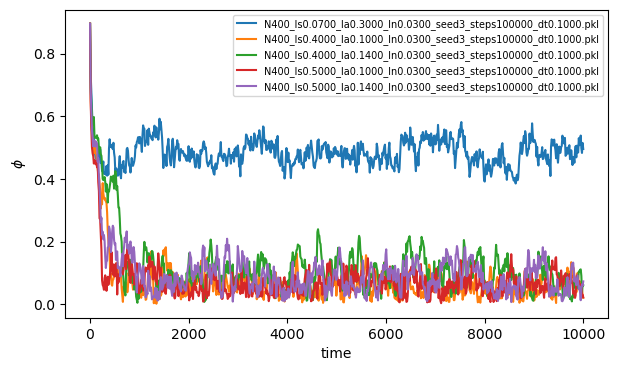

In [215]:
plt.figure(figsize=(7, 4))

for name, sim in sims.items():
    
    plt.plot(s["time"], s["phi"], label=name)

plt.xlabel("time")
plt.ylabel(r"$\phi$")
plt.legend(fontsize=7)
plt.show()

## C.3 Analysis

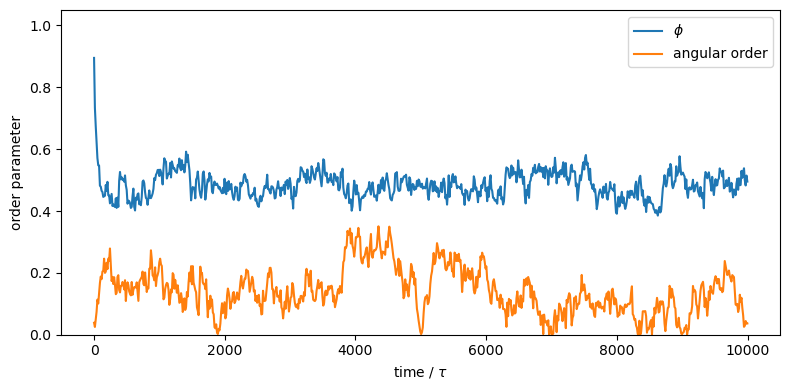

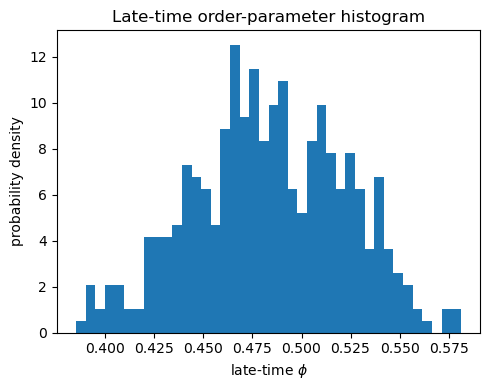

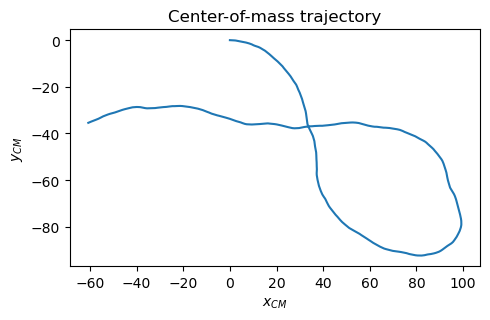

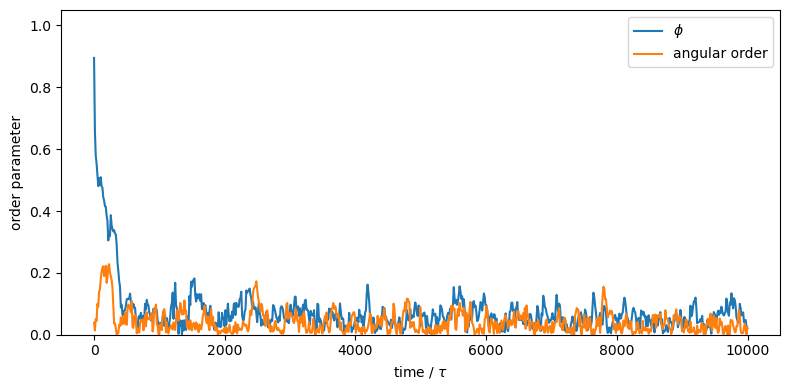

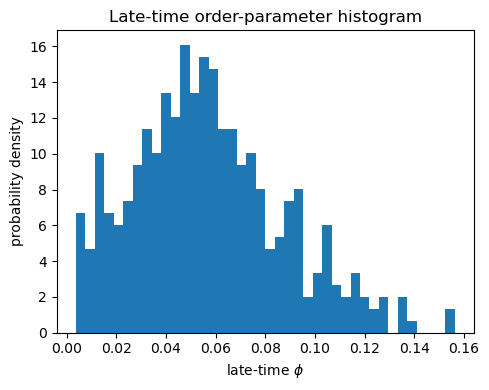

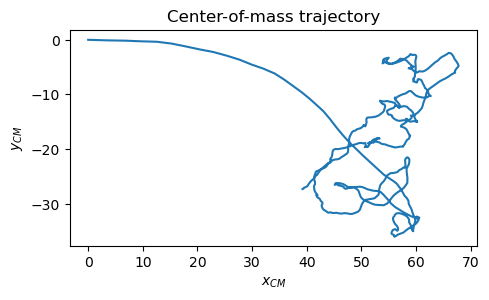

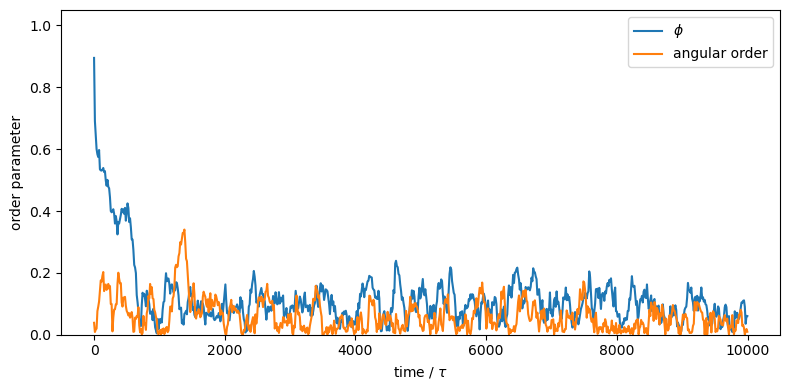

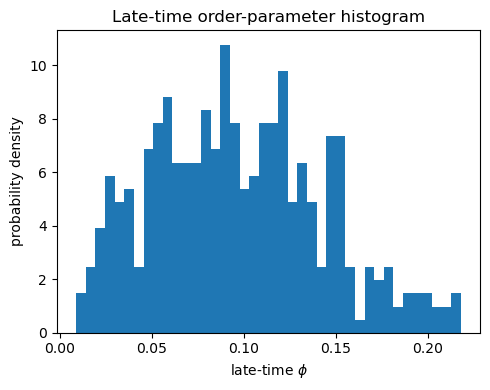

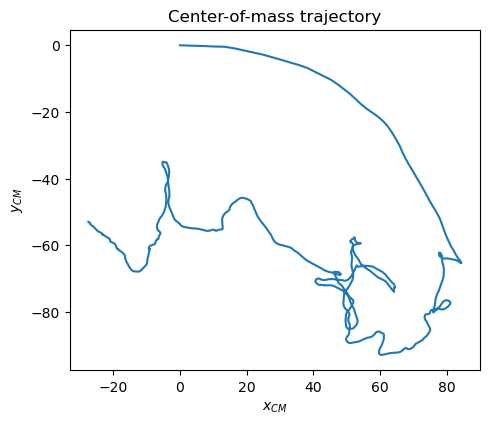

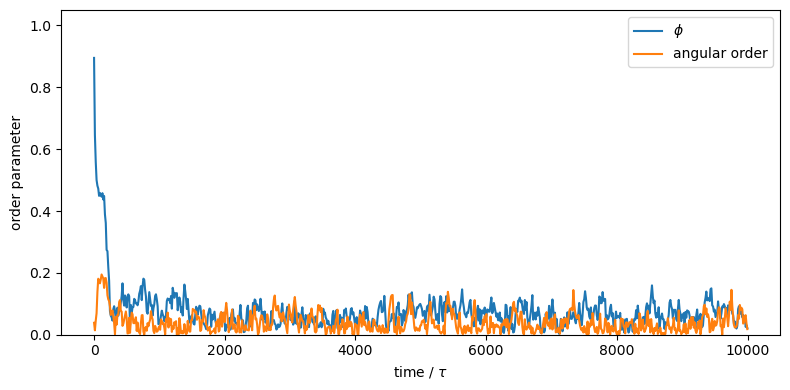

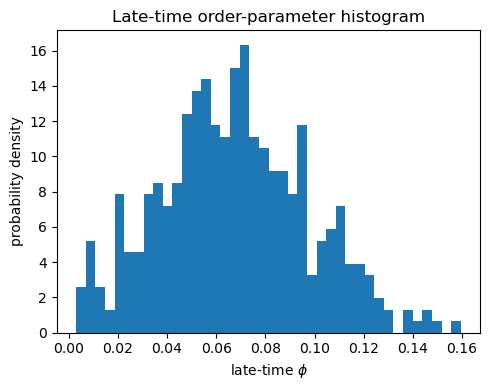

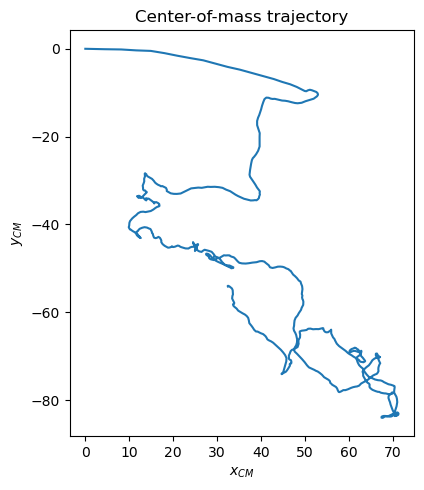

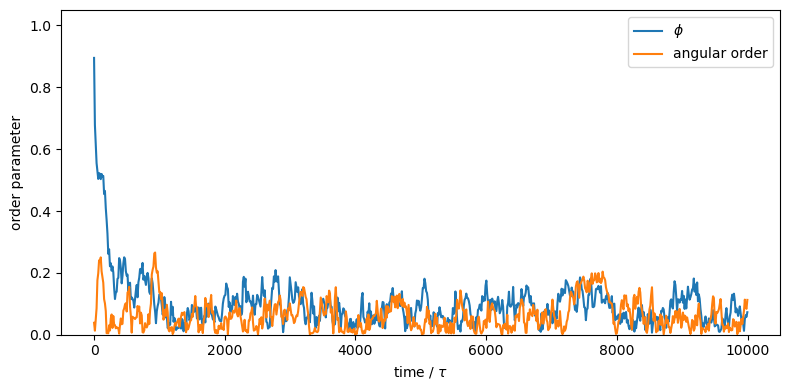

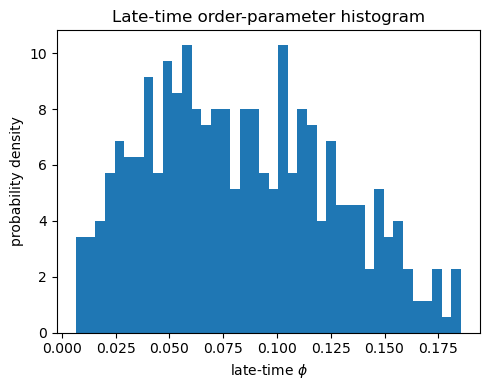

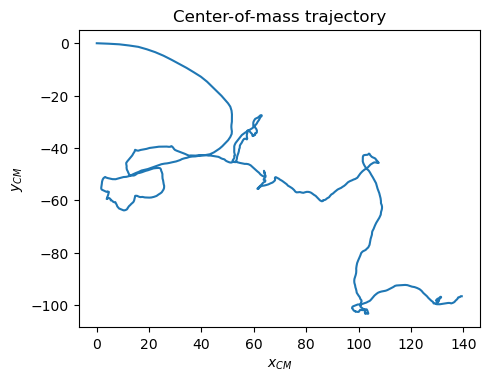

In [222]:
for name, sim in sims.items():
    s = sim["summary"]
    plot_summary(s)

## Part D: Animation and sccreenshot functions

In [232]:
def animate_snapshots(
    saved_snapshots,
    radii,
    interval=50,
    margin=5,
    title="Particle animation",
):
    """
    saved_snapshots shape: (n_frames, N, 3)
    saved_snapshots[t, i] = [x, y, theta]

    radii shape: (N,)
    """

    n_frames, N, _ = saved_snapshots.shape

    x = saved_snapshots[:, :, 0]
    y = saved_snapshots[:, :, 1]
    theta = saved_snapshots[:, :, 2]

    def compute_overlaps(x_frame, y_frame):
        overlaps = np.zeros(N)

        for i in range(N):
            for j in range(i + 1, N):
                dx = x_frame[j] - x_frame[i]
                dy = y_frame[j] - y_frame[i]
                d = np.sqrt(dx * dx + dy * dy)

                overlap = radii[i] + radii[j] - d

                if overlap > 0:
                    overlaps[i] += overlap
                    overlaps[j] += overlap

        return overlaps

    # Global color scale over the whole animation
    max_overlap = 0.0

    for frame in range(n_frames):
        overlaps = compute_overlaps(x[frame], y[frame])
        max_overlap = max(max_overlap, np.max(overlaps))

    norm = Normalize(vmin=0, vmax=max_overlap if max_overlap > 0 else 1.0)
    cmap = plt.cm.viridis  # dark blue -> green -> yellow

    fig, ax = plt.subplots(figsize=(6, 6))

    ax.set_xlim(np.min(x) - margin, np.max(x) + margin)
    ax.set_ylim(np.min(y) - margin, np.max(y) + margin)
    ax.set_aspect("equal")
    ax.set_xlabel("x")
    ax.set_ylabel("y")

    circles = []
    lines = []

    initial_overlaps = compute_overlaps(x[0], y[0])

    for i in range(N):
        circle = Circle(
            (x[0, i], y[0, i]),
            radii[i],
            facecolor=cmap(norm(initial_overlaps[i])),
            edgecolor="black",
            linewidth=0.3,
        )
        ax.add_patch(circle)
        circles.append(circle)

        end_x = x[0, i] + 0.7 * radii[i] * np.cos(theta[0, i])
        end_y = y[0, i] + 0.7 * radii[i] * np.sin(theta[0, i])

        line, = ax.plot(
            [x[0, i], end_x],
            [y[0, i], end_y],
            color="black",
            linewidth=0.5,
        )
        lines.append(line)

    sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
    sm.set_array([])

    #cbar = fig.colorbar(sm, ax=ax)
    #cbar.set_label("Overlap with neighbouring particles")

    title_text = ax.set_title(f"{title} | frame 0")

    def update(frame):
        overlaps = compute_overlaps(x[frame], y[frame])

        for i in range(N):
            xi = x[frame, i]
            yi = y[frame, i]
            ai = theta[frame, i]

            circles[i].center = (xi, yi)
            circles[i].set_facecolor(cmap(norm(overlaps[i])))

            end_x = xi + 0.7 * radii[i] * np.cos(ai)
            end_y = yi + 0.7 * radii[i] * np.sin(ai)

            lines[i].set_data([xi, end_x], [yi, end_y])

        title_text.set_text(f"{title} | frame {frame}")

        return circles + lines + [title_text]

    anim = FuncAnimation(
        fig,
        update,
        frames=n_frames,
        interval=interval,
        blit=True,
    )

    plt.close(fig)
    
    return anim

In [246]:
def plot_single_snapshot(
    snapshot,
    radii,
    margin=5,
    title="Particle snapshot",
    ax=None,
    overlap_vmax=None,
    show_colorbar=True,
):
    """
    Plot one saved snapshot in the same style as animate_snapshots.

    snapshot shape: (N, 3)
        snapshot[i] = [x, y, theta]

    radii shape: (N,)
        Particle radii
    """

    N = snapshot.shape[0]

    x = snapshot[:, 0]
    y = snapshot[:, 1]
    theta = snapshot[:, 2]

    def compute_overlaps(x_frame, y_frame):
        overlaps = np.zeros(N)

        for i in range(N):
            for j in range(i + 1, N):
                dx = x_frame[j] - x_frame[i]
                dy = y_frame[j] - y_frame[i]
                d = np.sqrt(dx * dx + dy * dy)

                overlap = radii[i] + radii[j] - d

                if overlap > 0:
                    overlaps[i] += overlap
                    overlaps[j] += overlap

        return overlaps

    overlaps = compute_overlaps(x, y)

    if overlap_vmax is None:
        overlap_vmax = np.max(overlaps)

    norm = Normalize(
        vmin=0,
        vmax=overlap_vmax if overlap_vmax > 0 else 1.0,
    )

    cmap = plt.cm.viridis

    if ax is None:
        fig, ax = plt.subplots(figsize=(6, 6))
    else:
        fig = ax.figure

    ax.set_xlim(np.min(x) - margin, np.max(x) + margin)
    ax.set_ylim(np.min(y) - margin, np.max(y) + margin)
    ax.set_aspect("equal")
    ax.set_xlabel("x")
    ax.set_ylabel("y")
    ax.set_title(title)

    for i in range(N):
        circle = Circle(
            (x[i], y[i]),
            radii[i],
            facecolor=cmap(norm(overlaps[i])),
            edgecolor="black",
            linewidth=0.3,
        )
        ax.add_patch(circle)

        end_x = x[i] + 0.7 * radii[i] * np.cos(theta[i])
        end_y = y[i] + 0.7 * radii[i] * np.sin(theta[i])

        ax.plot(
            [x[i], end_x],
            [y[i], end_y],
            color="black",
            linewidth=0.5,
        )

    if show_colorbar:
        sm = plt.cm.ScalarMappable(
            cmap=cmap,
            norm=norm,
        )
        sm.set_array([])


    return fig, ax

## Running for animation

In [226]:
params = ModelParameters(
    N=400,
    steps=10_000,
    save_every=128,
    snapshot_every=1000,
    snapshot_after=0,
    progress_every=10_000,
    dt=0.1,

    lambda_s=0.07,
    lambda_a=0.20,

    lambda_n=0.03,
    lambda_Fin=0.3,
    lambda_Tin=3.0,

    seed=3,
)

positions, angles, radii = initialize_particles(params)

summary = _run_simulation(
        positions,
        angles,
        radii,
        params
    )

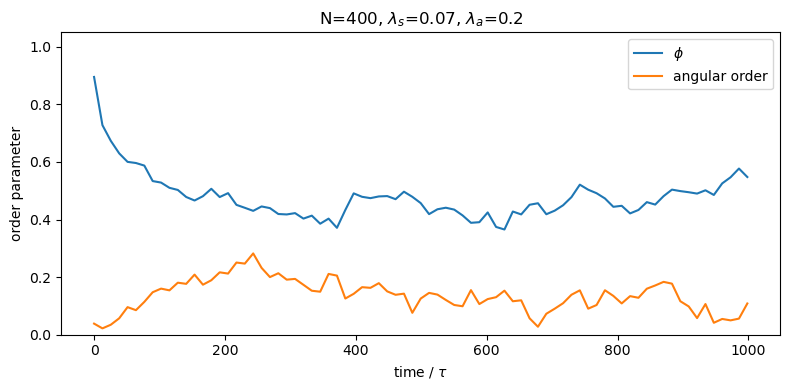

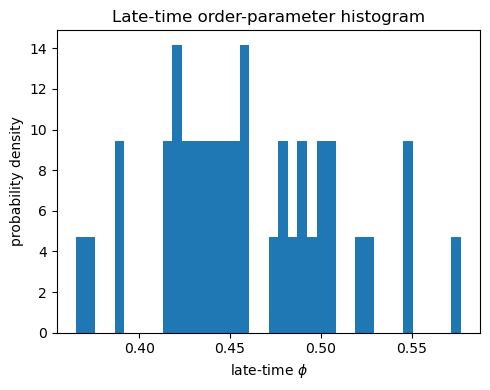

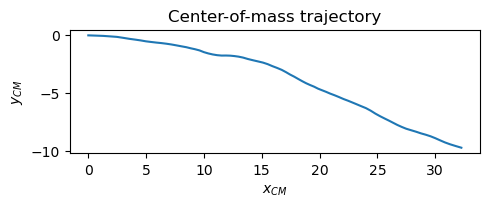

In [228]:
plot_summary(
    summary,
    title=fr"N={params.N}, $\lambda_s$={params.lambda_s}, $\lambda_a$={params.lambda_a}"
)

In [238]:
# Make GIF
anim = animate_snapshots(summary["saved_snapshots"], radii)

In [240]:
# Display GIF
HTML(anim.to_jshtml())

In [242]:
# Save GIF
writer = PillowWriter(fps=20)
filename = 'particles.gif'
anim.save(filename, writer=writer)
print(f"Saved GIF to: {filename}")

Saved GIF to: particles.gif


(<Figure size 600x600 with 1 Axes>,
 <Axes: title={'center': 'Particle snapshot'}, xlabel='x', ylabel='y'>)

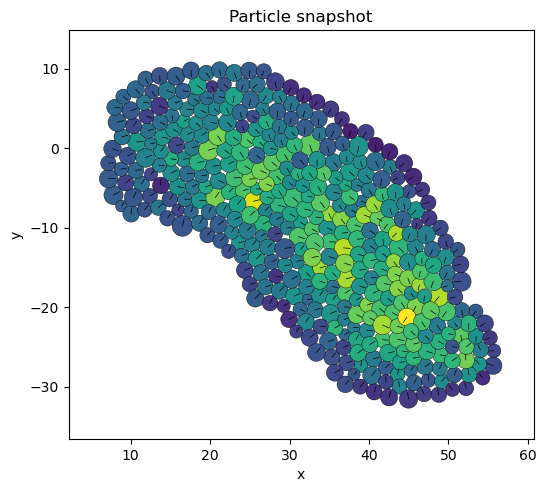

In [250]:
plot_single_snapshot(summary["saved_snapshots"][-1], radii)